# Data exploration — CNN/DailyMail

Dataset: CNN/DailyMail v3.0.0 (train split)
Rows sampled: 1,000

## Findings
- Columns: id, article, highlights
- No nulls found
- 0 duplicate articles found
- Average article length: ~4010.0 characters, ~687.0 words
- Articles range from 60.0 to 1862.0 words
- No HTML tags detected in raw text
- Text is clean prose — minimal preprocessing needed

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/meetm/Desktop/Projects/rag_news/data/train.csv", nrows=1000)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row keys and types:")
print(df.dtypes)

Shape: (1000, 3)

Columns: ['id', 'article', 'highlights']

First row keys and types:
id            str
article       str
highlights    str
dtype: object


In [3]:
print("=== ARTICLE ===")
print(df["article"][0])
print("\n=== HIGHLIGHTS ===")
print(df["highlights"][0])

=== ARTICLE ===
By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATED: . 15:36 EST, 25 October 2013 . The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October. The state Health Department has issued an advisory of exposure for anyone who attended five churches and took communion. Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A . State Immunization Program Manager Molly Howell says the risk is low, but officials feel it's important to alert people to the possible exposure. The diocese announced on Monday that Bishop John Folda is taking time off after being diagnosed with hepatitis A. The diocese says he contracted the infection through contaminated food while attending a conference for 

In [4]:
print("=== NULL CHECK ===")
print(df.isnull().sum())

print("\n=== DUPLICATE CHECK ===")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate articles:", df["article"].duplicated().sum())

print("\n=== ARTICLE LENGTH STATS (characters) ===")
df["article_len"] = df["article"].str.len()
print(df["article_len"].describe().round(0))

print("\n=== WORD COUNT STATS ===")
df["word_count"] = df["article"].str.split().str.len()
print(df["word_count"].describe().round(0))

=== NULL CHECK ===
id            0
article       0
highlights    0
dtype: int64

=== DUPLICATE CHECK ===
Duplicate rows: 0
Duplicate articles: 0

=== ARTICLE LENGTH STATS (characters) ===
count     1000.0
mean      4010.0
std       1911.0
min        325.0
25%       2558.0
50%       3712.0
75%       5051.0
max      11295.0
Name: article_len, dtype: float64

=== WORD COUNT STATS ===
count    1000.0
mean      687.0
std       328.0
min        60.0
25%       436.0
50%       638.0
75%       867.0
max      1862.0
Name: word_count, dtype: float64


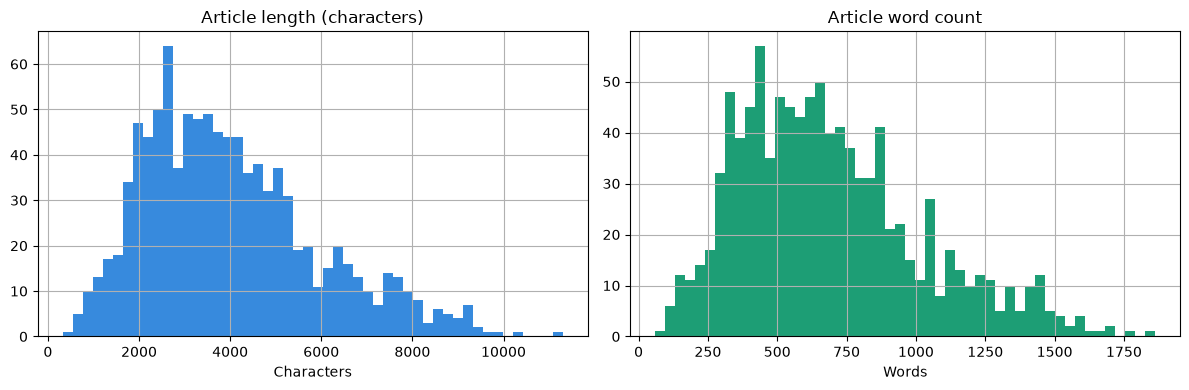

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["article_len"].hist(bins=50, ax=axes[0], color="#378ADD")
axes[0].set_title("Article length (characters)")
axes[0].set_xlabel("Characters")

df["word_count"].hist(bins=50, ax=axes[1], color="#1D9E75")
axes[1].set_title("Article word count")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.savefig("../docs/data_profile.png")
plt.show()